# 4.0 MLP(多层感知机)

### 隐藏层：增加判断层数
### 激活函数：
    对每个隐藏单元进行激活（非线性），否则增加隐藏层仍等价于单层（矩阵运算）
    1.relu函数（修正线性单元（Rectified linear unit，ReLU））：
      
<mi>ReLU</mi>
      <mo stretchy="false">(</mo>
      <mi>x</mi>
      <mo stretchy="false">)</mo>
      <mo>=</mo>
      <mo data-mjx-texclass="OP" movablelimits="true">max</mo>
      <mo stretchy="false">(</mo>
      <mi>x</mi>
      <mo>,</mo>
      <mn>0</mn>
      <mo stretchy="false">)</mo>
      <mo>.</mo>
      </math>

就是删掉负元素
    
    2. sigmoid函数：
   <math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>sigmoid</mi>
  <mo stretchy="false">(</mo>
  <mi>x</mi>
  <mo stretchy="false">)</mo>
  <mo>=</mo>
  <mfrac>
    <mn>1</mn>
    <mrow>
      <mn>1</mn>
      <mo>+</mo>
      <mi>exp</mi>
      <mo data-mjx-texclass="NONE">&#x2061;</mo>
      <mo stretchy="false">(</mo>
      <mo>&#x2212;</mo>
      <mi>x</mi>
      <mo stretchy="false">)</mo>
    </mrow>
  </mfrac>
  <mo>.</mo>
</math>


其导数：
<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mfrac>
    <mi>d</mi>
    <mrow>
      <mi>d</mi>
      <mi>x</mi>
    </mrow>
  </mfrac>
  <mi>sigmoid</mi>
  <mo stretchy="false">(</mo>
  <mi>x</mi>
  <mo stretchy="false">)</mo>
  <mo>=</mo>
  <mfrac>
    <mrow>
      <mi>exp</mi>
      <mo data-mjx-texclass="NONE">&#x2061;</mo>
      <mo stretchy="false">(</mo>
      <mo>&#x2212;</mo>
      <mi>x</mi>
      <mo stretchy="false">)</mo>
    </mrow>
    <mrow>
      <mo stretchy="false">(</mo>
      <mn>1</mn>
      <mo>+</mo>
      <mi>exp</mi>
      <mo data-mjx-texclass="NONE">&#x2061;</mo>
      <mo stretchy="false">(</mo>
      <mo>&#x2212;</mo>
      <mi>x</mi>
      <mo stretchy="false">)</mo>
      <msup>
        <mo stretchy="false">)</mo>
        <mn>2</mn>
      </msup>
    </mrow>
  </mfrac>
  <mo>=</mo>
  <mi>sigmoid</mi>
  <mo stretchy="false">(</mo>
  <mi>x</mi>
  <mo stretchy="false">)</mo>
  <mrow data-mjx-texclass="INNER">
    <mo data-mjx-texclass="OPEN">(</mo>
    <mn>1</mn>
    <mo>&#x2212;</mo>
    <mi>sigmoid</mi>
    <mo stretchy="false">(</mo>
    <mi>x</mi>
    <mo stretchy="false">)</mo>
    <mo data-mjx-texclass="CLOSE">)</mo>
  </mrow>
  <mo>.</mo>
</math>

    3.tanh函数：
<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>tanh</mi>
  <mo stretchy="false">(</mo>
  <mi>x</mi>
  <mo stretchy="false">)</mo>
  <mo>=</mo>
  <mfrac>
    <mrow>
      <mn>1</mn>
      <mo>&#x2212;</mo>
      <mi>exp</mi>
      <mo data-mjx-texclass="NONE">&#x2061;</mo>
      <mo stretchy="false">(</mo>
      <mo>&#x2212;</mo>
      <mn>2</mn>
      <mi>x</mi>
      <mo stretchy="false">)</mo>
    </mrow>
    <mrow>
      <mn>1</mn>
      <mo>+</mo>
      <mi>exp</mi>
      <mo data-mjx-texclass="NONE">&#x2061;</mo>
      <mo stretchy="false">(</mo>
      <mo>&#x2212;</mo>
      <mn>2</mn>
      <mi>x</mi>
      <mo stretchy="false">)</mo>
    </mrow>
  </mfrac>
  <mo>.</mo>
</math>

#### 思考
这些激活函数有什么意义？
1. 首先是一个非线性的变换，让权重的作用影响能够更精确描绘。类似一个和线性的补充，其越丰富，就越可能找到更合理的选择？
2. 激活值判定。但也可能让部分神经元没用
3. 防止一些可能的梯度爆炸？ *看到Qwen的什么东西来着，加了一个gating什么的就大幅减少了损失掉了的情况*


## 4.1 多层感知机从零实现


In [ ]:
import torch
from torch import nn
from d2l import torch as d2l
import nbimporter
import py文件.functions_needed as functions_needed 

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

### 初始化参数模型：
< 记得复习前面的，代码能力太弱容易搞忘

In [8]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256

W1 = nn.Parameter(torch.randn(
    num_inputs, num_hiddens, requires_grad=True) * 0.01)  #Parameter 参数，*0.01防止权重过大（导致之后的梯度爆炸）
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
W2 = nn.Parameter(torch.randn(
    num_hiddens, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [W1, b1, W2, b2] #储存在一起以便之后调用？

### 激活函数
选择Relu函数

In [9]:
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)#真tm直接

### 模型（net）
转换图像为张量（边看边算复习了，上周事太多了）

In [10]:
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X@W1 + b1)
    return (H@W2 + b2) #一步到位

### 损失函数

In [11]:
loss = nn.CrossEntropyLoss(reduction='none')
help(nn.CrossEntropyLoss)

Help on class CrossEntropyLoss in module torch.nn.modules.loss:

class CrossEntropyLoss(_WeightedLoss)
 |  CrossEntropyLoss(weight: Optional[torch.Tensor] = None, size_average=None, ignore_index: int = -100, reduce=None, reduction: str = 'mean', label_smoothing: float = 0.0) -> None
 |  
 |  This criterion computes the cross entropy loss between input logits
 |  and target.
 |  
 |  It is useful when training a classification problem with `C` classes.
 |  If provided, the optional argument :attr:`weight` should be a 1D `Tensor`
 |  assigning weight to each of the classes.
 |  This is particularly useful when you have an unbalanced training set.
 |  
 |  The `input` is expected to contain the unnormalized logits for each class (which do `not` need
 |  to be positive or sum to 1, in general).
 |  `input` has to be a Tensor of size :math:`(C)` for unbatched input,
 |  :math:`(minibatch, C)` or :math:`(minibatch, C, d_1, d_2, ..., d_K)` with :math:`K \geq 1` for the
 |  `K`-dimensional cas

补几个softmax里面的函数
< 不用补了，换到vscode了，tmd我之前过的什么苦日子，一个字母一个字母手敲

### 训练

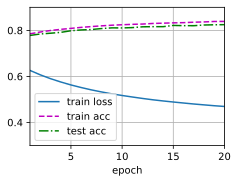

In [13]:
num_epochs, lr = 20, 0.01
updater = torch.optim.SGD(params,lr=lr)

functions_needed.train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)

## 4.2 简洁实现
记得仔细看具体代码的底层逻辑

In [14]:
import torch
from torch import nn
from d2l import torch as d2l

In [16]:
help(nn.Linear)

Help on class Linear in module torch.nn.modules.linear:

class Linear(torch.nn.modules.module.Module)
 |  Linear(in_features: int, out_features: int, bias: bool = True, device=None, dtype=None) -> None
 |  
 |  Applies an affine linear transformation to the incoming data: :math:`y = xA^T + b`.
 |  
 |  This module supports :ref:`TensorFloat32<tf32_on_ampere>`.
 |  
 |  On certain ROCm devices, when using float16 inputs this module will use :ref:`different precision<fp16_on_mi200>` for backward.
 |  
 |  Args:
 |      in_features: size of each input sample
 |      out_features: size of each output sample
 |      bias: If set to ``False``, the layer will not learn an additive bias.
 |          Default: ``True``
 |  
 |  Shape:
 |      - Input: :math:`(*, H_{in})` where :math:`*` means any number of
 |        dimensions including none and :math:`H_{in} = \text{in\_features}`.
 |      - Output: :math:`(*, H_{out})` where all but the last dimension
 |        are the same shape as the input 

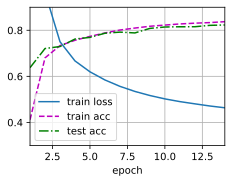

In [19]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.Sigmoid(),
                    nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)


batch_size, lr, num_epochs = 256, 0.1, 14
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)

train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
functions_needed.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)